In [ ]:
#!pip install yfinance
# Thêm các thư viện cần thiết
import pandas as pd
from pandas_datareader import data as pdr
import numpy as np
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from tensorflow.keras.models import Model
from keras.layers import LSTM, Dense, Bidirectional, Dropout, Input, Concatenate
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import History
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Activation
from keras.layers import Conv1D, MaxPooling1D, Flatten, AveragePooling1D
!pip install keras-self-attention
from keras_self_attention import SeqSelfAttention
from tensorflow.keras.layers import MultiHeadAttention
!pip install attention
from attention import Attention

In [ ]:
data_ORCL = pd.read_csv('ORCL.csv')

data_ORCL

,Date,Close,Open,High,Low,Adj Close,Volume,MACD,MFI,RSI,ATR
0,2019-12-31,52.980000,52.570000,53.000000,52.549999,49.294575,7094500,-0.658542,47.794937,37.311870,0.725588
1,2020-01-02,53.950001,53.270000,53.959999,53.230000,50.197102,13899600,-0.584446,48.129089,47.035337,0.743761
2,2020-01-03,53.759998,52.990002,54.049999,52.950001,50.020325,11026700,-0.534891,40.548907,45.545121,0.769206
3,2020-01-06,54.040001,53.360001,54.200001,53.349998,50.280849,10982400,-0.467633,49.636393,48.152135,0.774977
4,2020-01-07,54.160000,53.889999,54.330002,53.610001,50.392494,12015400,-0.400036,59.595826,49.272981,0.771050
...,...,...,...,...,...,...,...,...,...,...,...
1105,2024-05-22,124.599998,124.629997,125.160004,123.300003,124.599998,5705000,1.417709,74.905685,67.306719,2.117463
1106,2024-05-23,124.089996,126.550003,126.699997,123.160004,124.089996,6108600,1.523661,75.480460,64.825717,2.219072
1107,2024-05-24,122.910004,123.419998,123.510002,121.419998,122.910004,7166100,1.495178,67.691852,59.372577,2.251281
1108,2024-05-28,124.489998,123.239998,124.820000,123.010002,124.489998,6911400,1.581862,67.981634,63.767565,2.226904


In [ ]:
data = data_ORCL
epoch = 500
#columns = ['Close']
columns = ['Close', 'Open', 'High', 'Low']
#columns = ['Close', 'Open', 'High', 'Low', 'Volume']
#columns = ['Close', 'MACD', 'MFI', 'RSI', 'ATR']
#columns = ['Close', 'Open', 'High', 'Low', 'Volume', 'MACD', 'MFI', 'RSI', 'ATR']
#columns = ['Close', 'Open', 'High', 'Low', 'Volume', 'MACD', 'MFI', 'RSI', 'ATR', 'USD/VND', 'IR', 'CFI', 'Broad money M2']
#columns = ['Close', 'Open', 'High', 'Low', 'Volume', 'MACD', 'MFI', 'RSI', 'ATR', 'USD/VND', 'IR', 'CFI']

data = data[columns]

train_size = int(len(data) * 0.9)

train = data[:train_size]
test = data['Close']
test = data[train_size:]

train = train[columns]

scaler = MinMaxScaler(feature_range = (0, 1))

# train_scaled = scaler.fit_transform(train)
# test_scaled = scaler.transform(data)
scaled = scaler.fit_transform(data)
train_scaled = scaled[:int(train_size)]

test_data_lb_7day = scaled[int(train_size) - 7: , :]
test_data_lb_14day = scaled[int(train_size) - 14: , :]
test_data_lb_21day = scaled[int(train_size) - 21: , :]

In [ ]:
def create_bilstm_parallel(input_layer, units, dropout_rate):
    bilstm = Bidirectional(LSTM(units=units, return_sequences=True))(input_layer)

    #bilstm = Bidirectional(LSTM(units=units, return_sequences=True))(bilstm)
    #bilstm = Dropout(dropout_rate)(bilstm)

    #bilstm = SeqSelfAttention(attention_activation='elu')(bilstm)
    bilstm = Attention(units=units)(bilstm)

    return bilstm

def parallel_bilstm_model(train_scaled, test_scaled, lb, batchsize):
    X_train = []
    Y_train = []

    for i in range(lb, len(train_scaled)):
        X_train.append(train_scaled[i - lb:i, :])
        Y_train.append(train_scaled[i, 0])

    X_train, Y_train = np.array(X_train), np.array(Y_train)
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], len(columns)))
    x_train, x_val, y_train, y_val = train_test_split(X_train, Y_train, test_size=0.1)

    start_time = time.time()
    history = History()
    early_stopping = EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)

    input_layer = Input(shape=(x_train.shape[1], x_train.shape[2]))

    bilstm1 = create_bilstm_parallel(input_layer, units=128, dropout_rate=0.3)
    bilstm2 = create_bilstm_parallel(input_layer, units=128, dropout_rate=0.3)

    concatenated = Concatenate()([bilstm1, bilstm2])

    concatenated = Flatten()(concatenated)

    dense = Dense(units=128, activation='sigmoid')(concatenated)
    output = Dense(units=1)(dense)

    model = Model(inputs=input_layer, outputs=output)

    # Compile the model
    model.compile(optimizer='adam', loss='mse')
    # Train the model
    model.fit(x_train, y_train, epochs=epoch, validation_data=(x_val, y_val),
              batch_size=batchsize, callbacks=[history, early_stopping])

    end_time = time.time()
    training_time = end_time - start_time

    loss = history.history['loss']
    val_loss = history.history['val_loss']
    plt.plot(loss, label='Training Loss')
    plt.plot(val_loss, label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    x_test = []
    for i in range(lb, len(test_scaled)):
      x_test.append(test_scaled[i - lb:i, :])
    x_test = np.array(x_test)
    x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], len(columns)))

    predictions = model.predict(x_test)
    predictions = predictions.reshape(-1, 1)
    X = np.random.rand(int(len(test)), int(len(columns) - 1))
    predictions = np.hstack((predictions, X))
    predictions = scaler.inverse_transform(predictions)

    return predictions[:, 0], training_time

Epoch 1/500
14/14 [==============================] - 10s 120ms/step - loss: 0.1254 - val_loss: 0.0301
Epoch 2/500
14/14 [==============================] - 0s 13ms/step - loss: 0.0158 - val_loss: 0.0072
Epoch 3/500
14/14 [==============================] - 0s 13ms/step - loss: 0.0040 - val_loss: 0.0012
Epoch 4/500
14/14 [==============================] - 0s 16ms/step - loss: 0.0017 - val_loss: 0.0010
Epoch 5/500
14/14 [==============================] - 0s 12ms/step - loss: 9.0781e-04 - val_loss: 8.0888e-04
Epoch 6/500
14/14 [==============================] - 0s 13ms/step - loss: 8.0762e-04 - val_loss: 7.3430e-04
Epoch 7/500
14/14 [==============================] - 0s 13ms/step - loss: 7.8695e-04 - val_loss: 7.1160e-04
Epoch 8/500
14/14 [==============================] - 0s 12ms/step - loss: 7.2530e-04 - val_loss: 6.7964e-04
Epoch 9/500
14/14 [==============================] - 0s 14ms/step - loss: 7.0623e-04 - val_loss: 6.4939e-04
Epoch 10/500
14/14 [==============================] - 0s 1

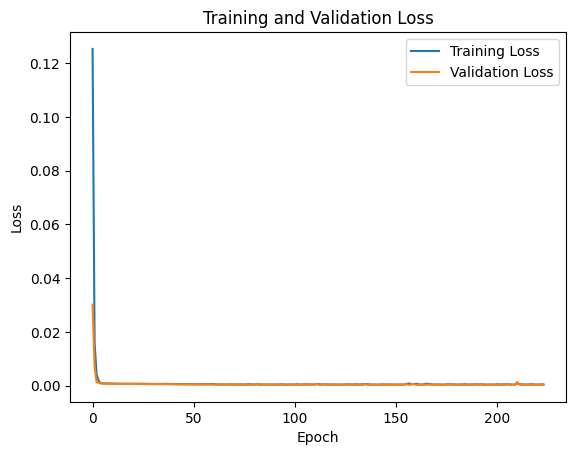

4/4 [==============================] - 2s 8ms/step


In [ ]:
predictions_lb_7day, training_time_lb_7day = parallel_bilstm_model(train_scaled, test_data_lb_7day, 7, 64)

Epoch 1/500
10/10 [==============================] - 8s 168ms/step - loss: 0.0956 - val_loss: 0.0278
Epoch 2/500
10/10 [==============================] - 0s 17ms/step - loss: 0.0188 - val_loss: 0.0136
Epoch 3/500
10/10 [==============================] - 0s 17ms/step - loss: 0.0082 - val_loss: 0.0065
Epoch 4/500
10/10 [==============================] - 0s 15ms/step - loss: 0.0036 - val_loss: 0.0028
Epoch 5/500
10/10 [==============================] - 0s 15ms/step - loss: 0.0016 - val_loss: 0.0016
Epoch 6/500
10/10 [==============================] - 0s 15ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 7/500
10/10 [==============================] - 0s 17ms/step - loss: 0.0012 - val_loss: 0.0012
Epoch 8/500
10/10 [==============================] - 0s 13ms/step - loss: 0.0010 - val_loss: 0.0013
Epoch 9/500
10/10 [==============================] - 0s 14ms/step - loss: 0.0010 - val_loss: 0.0011
Epoch 10/500
10/10 [==============================] - 0s 16ms/step - loss: 9.6076e-04 - val_loss: 0

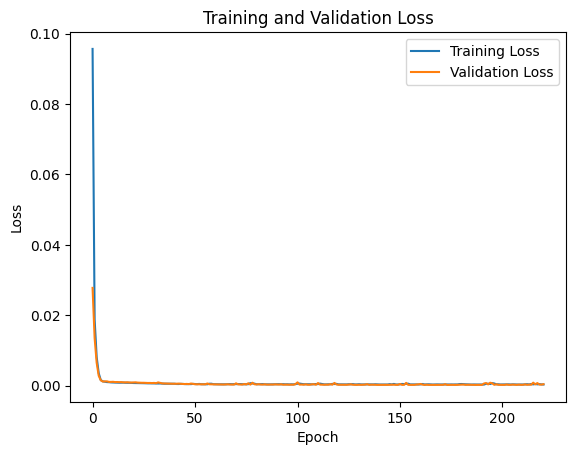

4/4 [==============================] - 1s 6ms/step


In [ ]:
predictions_lb_14day, training_time_lb_14day = parallel_bilstm_model(train_scaled, test_data_lb_14day, 14, 96)

Epoch 1/500
14/14 [==============================] - 9s 125ms/step - loss: 0.0599 - val_loss: 0.0074
Epoch 2/500
14/14 [==============================] - 0s 15ms/step - loss: 0.0071 - val_loss: 0.0078
Epoch 3/500
14/14 [==============================] - 0s 22ms/step - loss: 0.0028 - val_loss: 0.0027
Epoch 4/500
14/14 [==============================] - 0s 21ms/step - loss: 0.0017 - val_loss: 0.0021
Epoch 5/500
14/14 [==============================] - 0s 22ms/step - loss: 0.0013 - val_loss: 0.0019
Epoch 6/500
14/14 [==============================] - 0s 22ms/step - loss: 0.0012 - val_loss: 0.0019
Epoch 7/500
14/14 [==============================] - 0s 22ms/step - loss: 0.0011 - val_loss: 0.0016
Epoch 8/500
14/14 [==============================] - 0s 23ms/step - loss: 0.0010 - val_loss: 0.0016
Epoch 9/500
14/14 [==============================] - 0s 23ms/step - loss: 9.9488e-04 - val_loss: 0.0016
Epoch 10/500
14/14 [==============================] - 0s 21ms/step - loss: 9.6761e-04 - val_los

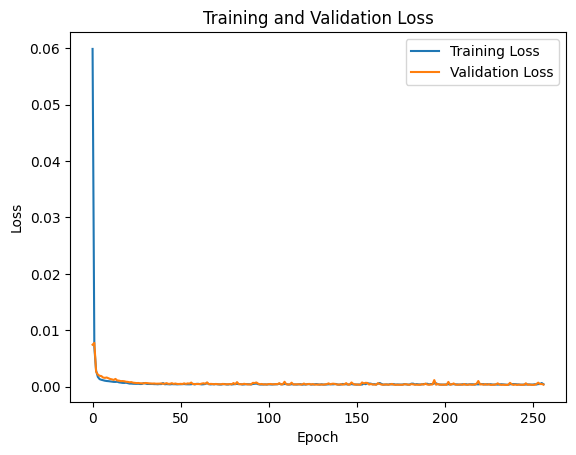

4/4 [==============================] - 1s 6ms/step


In [ ]:
predictions_lb_21day, training_time_lb_21day = parallel_bilstm_model(train_scaled, test_data_lb_21day, 21, 64)

In [ ]:
data_visual = data_ORCL.filter(['Date', 'Close'])
data_visual['Date'] = pd.to_datetime(data_visual['Date'])
valid = data_visual[train_size:]

valid['Predictions lb 7 day'] = predictions_lb_7day
valid['Predictions lb 14 day'] = predictions_lb_14day
valid['Predictions lb 21 day'] = predictions_lb_21day

valid

<ipython-input-66-33984e91cc03>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions lb 7 day'] = predictions_lb_7day
<ipython-input-66-33984e91cc03>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions lb 14 day'] = predictions_lb_14day
<ipython-input-66-33984e91cc03>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.

,Date,Close,Predictions lb 7 day,Predictions lb 14 day,Predictions lb 21 day
999,2023-12-19,106.250000,104.165838,104.198486,104.862301
1000,2023-12-20,104.150002,105.137186,105.416170,105.851001
1001,2023-12-21,105.860001,104.045437,104.511167,104.526227
1002,2023-12-22,106.199997,105.290085,105.485249,105.506589
1003,2023-12-26,106.190002,105.937092,106.185156,106.137486
...,...,...,...,...,...
1105,2024-05-22,124.599998,124.413415,124.527622,124.464305
1106,2024-05-23,124.089996,124.152296,124.380635,124.230758
1107,2024-05-24,122.910004,124.281755,124.341105,124.170000
1108,2024-05-28,124.489998,122.628247,122.814018,122.506961


In [ ]:
def calculateAccurary(prediction, close):

  mse = mean_squared_error(close, prediction)
  rmse = np.sqrt(mse)
  mae = mean_absolute_error(close, prediction)
  mape = mean_absolute_percentage_error(close, prediction)
  r2 = r2_score(close, prediction)

  print("RMSE:", round(rmse, 5))
  print("MSE :", round(mse, 5))
  print("MAE :", round(mae, 5))
  print("MAPE:", round(mape, 5))`
  print("R^2 :", round(r2, 5))
  print()

print("Bi LSTM Lb 7 day")
print("Training time Bi LSTM:", round(training_time_lb_7day, 2), "seconds", "=", round(training_time_lb_7day/60, 2), "minutes")
calculateAccurary(valid['Predictions lb 7 day'], valid["Close"])

print("Bi LSTM Lb 14 day")
print("Training time Bi LSTM:", round(training_time_lb_14day, 2), "seconds", "=", round(training_time_lb_14day/60, 2), "minutes")
calculateAccurary(valid['Predictions lb 14 day'], valid["Close"])

print("Bi LSTM Lb 21 day")
print("Training time Bi LSTM:", round(training_time_lb_21day, 2), "seconds", "=", round(training_time_lb_21day/60, 2), "minutes")
calculateAccurary(valid['Predictions lb 21 day'], valid["Close"])

Bi LSTM Lb 7 day
Training time Bi LSTM: 55.17 seconds = 0.92 minutes
RMSE: 1.99
MSE : 3.97
MAE : 1.27
MAPE: 0.01
R^2 : 0.92

Bi LSTM Lb 14 day
Training time Bi LSTM: 46.63 seconds = 0.78 minutes
RMSE: 2.02
MSE : 4.07
MAE : 1.29
MAPE: 0.01
R^2 : 0.92

Bi LSTM Lb 21 day
Training time Bi LSTM: 67.16 seconds = 1.12 minutes
RMSE: 1.99
MSE : 3.97
MAE : 1.28
MAPE: 0.01
R^2 : 0.92



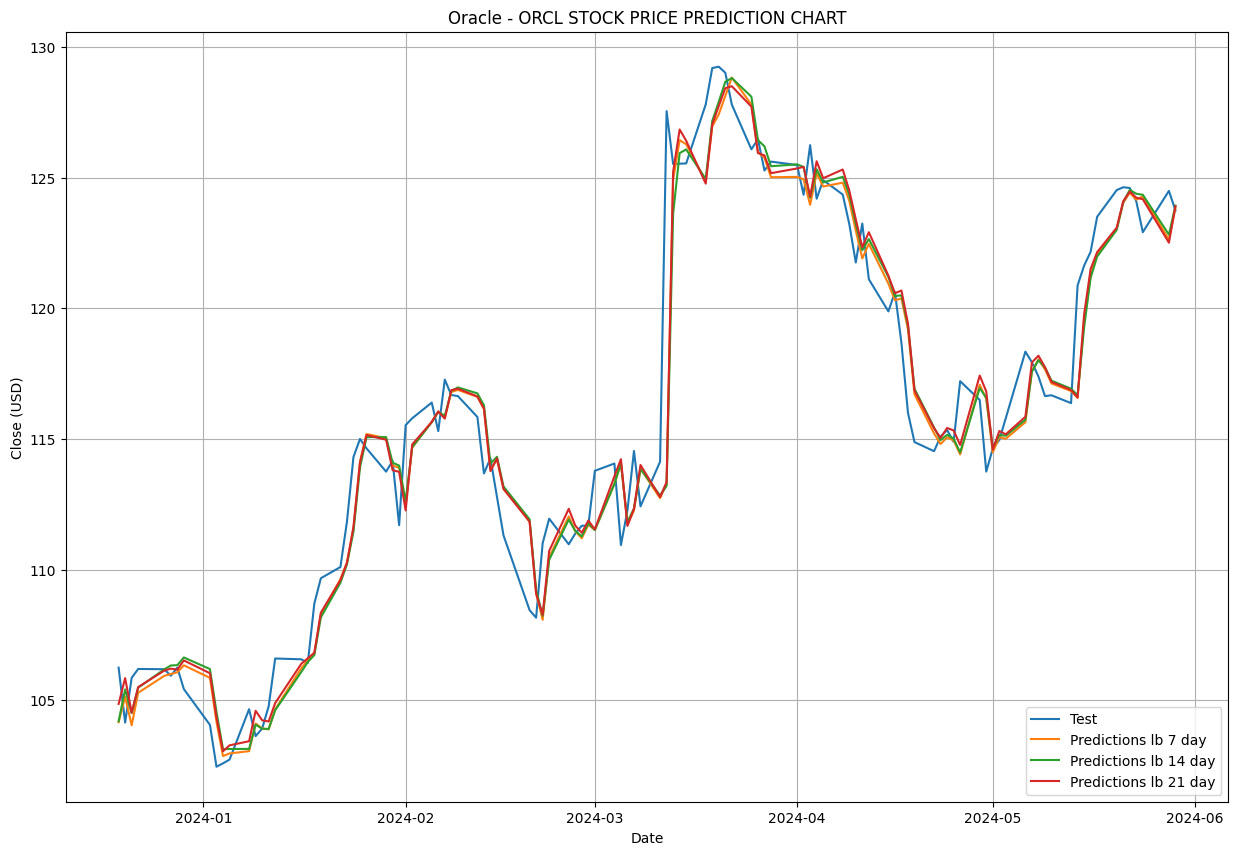

In [ ]:
# Draw a historial of closing price
plt.figure(figsize=(15, 10))

plt.plot(valid['Date'], valid['Close'])
plt.plot(valid['Date'], valid['Pre`dictions lb 7 day'])
plt.plot(valid['Date'], valid['Predictions lb 14 day'])
plt.plot(valid['Date'], valid['Predictions lb 21 day'])
plt.ylabel('Close (USD)', fontsize=16)
plt.ylabel('Close (USD)', fontsize=16)
plt.xlabel('Date', fontsize=16)
plt.title(f"ORCL STOCK PRICE PREDICTION CHART - PARALLEL Bi LSTM-ATTENTION", fontsize=18)
plt.legend(['Actual Closing Price', 'Predicted Closing Price - Lookback  7 days',
            'Predicted Closing Price - Lookback 14 days', 'Predicted Closing Price - Lookback 21 days'], loc='lower right', fontsize=14)
plt.grid(True)
plt.tick_params(axis='x', labelsize=14)
plt.tick_params(axis='y', labelsize=14)
plt.show()
